# Correct the Moloch forecast with Milan Observation

In [1]:
# import class and functions from other scripts
import datasets_forecast as ds

In [2]:
from google.cloud import bigquery
from google.cloud import storage
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from decimal import *
from calendar import monthrange, month_abbr
import cartopy as ctp
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.io import shapereader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import io
import base64
import pygrib
import math
import netCDF4
import pytz
import cmocean
import seaborn as sns
from sklearn.metrics import mean_squared_error, confusion_matrix
import matplotlib.dates as mdates
from pytz import timezone, all_timezones
from scipy.stats import spearmanr, pearsonr, linregress
import scipy.signal as signal
from scipy.interpolate import interp1d
from taylor_diagram import TaylorDiagram
import statsmodels.api as sm
import os
import difflib
import folium
from folium.plugins import MarkerCluster, BeautifyIcon
from PIL import Image, ImageDraw
import warnings
import properscoring as ps
import numba
import pprint
from geopy.distance import geodesic
import xarray as xr
from calendar import monthrange
import difflib

In [3]:
plt.rcParams['text.usetex'] = True

## Load Dataset

In [4]:
milan=(45.36, 45.54, 9.03, 9.29)


In [5]:
def load_moloch_forecast_from_csv():
    """
    Load the Moloch forecast dataset from CSV files.

    Returns
    -------
    pandas.DataFrame
        The loaded dataset.
    """
    
    i=0
    for year in range(2021,2025):
        filename = f'forecast_moloch/forecast_milan_{year}.csv'
        if os.path.exists(filename):
            print(f"Loading data from {filename}")
            data = pd.read_csv(filename, parse_dates=['TIME', 'DATA_FORECAST'])
            if i==0:
                all_data= data.copy()
                i+=1
            else:
                all_data = pd.concat([all_data, data], ignore_index=True)
      

    # format the columns
    all_data['TIME'] = pd.to_datetime(all_data['TIME'], utc=True)
    all_data['DATA_FORECAST'] = pd.to_datetime(all_data['DATA_FORECAST'], utc=True)

    print(all_data.columns)

    # open moloch_gridpoints to add the ID of the associated observation point
    gridpoints = pd.read_csv('forecast_moloch/moloch_gridpoints.csv')
    all_data = all_data.merge(gridpoints[['ID', 'ID_CONSUNTIVO']], how='left')

    # rename columns
    all_data.rename(columns={
        'X': 'X',
        'Y': 'Y',
        'LONGITUDINE': 'LON',
        'LATITUDINE': 'LAT',
        'VALORE': 'VALUE',
        'NOME_VARIABILE': 'VAR_NAME'
    }, inplace=True)
     
    return all_data

In [6]:
forecast_moloch = load_moloch_forecast_from_csv()

Loading data from forecast_moloch/forecast_milan_2021.csv
Loading data from forecast_moloch/forecast_milan_2022.csv
Loading data from forecast_moloch/forecast_milan_2023.csv
Loading data from forecast_moloch/forecast_milan_2024.csv
Index(['FLOW_ID', 'FLOW_DATE', 'FLOW_EXEC', 'PUBLICATION_DT', 'FILE_NAME',
       'MODELLO', 'ID', 'X', 'Y', 'LATITUDINE', 'LONGITUDINE', 'DATA_FORECAST',
       'TIME', 'NOME_VARIABILE', 'VALORE', 'PROVIDER_ID'],
      dtype='object')


In [7]:
forecast_moloch

,FLOW_ID,FLOW_DATE,FLOW_EXEC,PUBLICATION_DT,FILE_NAME,MODELLO,ID,X,Y,LAT,LON,DATA_FORECAST,TIME,VAR_NAME,VALUE,PROVIDER_ID,ID_CONSUNTIVO
0,ARPAL_FORECAST_DATA_00,2020-12-28,91731051442803,NaN,molita15sfc_2021010100.csv,molita15sfc_2021010100,904745.0,717.0,278.0,45.438681,9.273625,2021-01-01 00:00:00+00:00,2021-01-01 00:00:00+00:00,t2,273.43304,ARPAL,NaN
1,ARPAL_FORECAST_DATA_00,2020-12-28,91731051442803,NaN,molita15sfc_2021010100.csv,molita15sfc_2021010100,900406.0,712.0,278.0,45.368681,9.273289,2021-01-01 00:00:00+00:00,2021-01-01 00:00:00+00:00,t2,273.19086,ARPAL,NaN
2,ARPAL_FORECAST_DATA_00,2020-12-28,91731051442803,NaN,molita15sfc_2021010100.csv,molita15sfc_2021010100,902535.0,722.0,268.0,45.508981,9.074199,2021-01-01 00:00:00+00:00,2021-01-01 00:00:00+00:00,t2,273.43500,ARPAL,501239.0
3,ARPAL_FORECAST_DATA_00,2020-12-28,91731051442803,NaN,molita15sfc_2021010100.csv,molita15sfc_2021010100,904481.0,717.0,276.0,45.438768,9.233722,2021-01-01 00:00:00+00:00,2021-01-01 00:00:00+00:00,t2,273.38226,ARPAL,NaN
4,ARPAL_FORECAST_DATA_00,2020-12-28,91731051442803,NaN,molita15sfc_2021010100.csv,molita15sfc_2021010100,904488.0,719.0,271.0,45.466927,9.134029,2021-01-01 00:00:00+00:00,2021-01-01 00:00:00+00:00,t2,273.41644,ARPAL,501175.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2889175,ARPAL_FORECAST_DATA_18,2024-12-31,91745920394683,NaN,molita15sfc_2024123118.csv,molita15sfc_2024123118,904481.0,717.0,276.0,45.438768,9.233722,2024-12-31 18:00:00+00:00,2025-01-02 18:00:00+00:00,t2,277.28372,ARPAL,NaN
2889176,ARPAL_FORECAST_DATA_18,2024-12-31,91745920394683,NaN,molita15sfc_2024123118.csv,molita15sfc_2024123118,904486.0,719.0,272.0,45.466902,9.153990,2024-12-31 18:00:00+00:00,2025-01-02 18:00:00+00:00,t2,277.26320,ARPAL,NaN
2889177,ARPAL_FORECAST_DATA_18,2024-12-31,91745920394683,NaN,molita15sfc_2024123118.csv,molita15sfc_2024123118,904490.0,722.0,278.0,45.508680,9.273962,2024-12-31 18:00:00+00:00,2025-01-02 18:00:00+00:00,t2,276.99954,ARPAL,NaN
2889178,ARPAL_FORECAST_DATA_18,2024-12-31,91745920394683,NaN,molita15sfc_2024123118.csv,molita15sfc_2024123118,900370.0,721.0,278.0,45.494680,9.273895,2024-12-31 18:00:00+00:00,2025-01-02 18:00:00+00:00,t2,277.70560,ARPAL,501173.0


In [8]:
def plot_distribution_forecast_moloch(forecast, var='t2'):
    """
    plot the distribution of the forecast for a given variable
    
    Parameters
    ----------
    forecast: the dataset with the forecast
    var: the variable to plot
    """


    ############# plot map of the gridpoints with the forecast data

    colorlist = sns.color_palette("Spectral", forecast.groupby(['X', 'Y']).ngroups)
    colordict= {key: color for key, color in zip(forecast.groupby(['X', 'Y']).groups.keys(), colorlist)}
    forecast['COLOR'] = forecast.apply(lambda row: colordict[(row['X'], row['Y'])], axis=1)

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([forecast['LON'].min()-0.05, forecast['LON'].max()+0.05,
                   forecast['LAT'].min()-0.05, forecast['LAT'].max()+0.05], crs=ccrs.PlateCarree())


    # Plot the contour of the Comune di Milano
    milano_shp = shapereader.Reader("shapefiles/L090102_ComuneMilano.shp")
    milano_geom = [record.geometry for record in milano_shp.records()]
    milano_gdf = gpd.GeoDataFrame(geometry=milano_geom, crs='EPSG:3003')  # Roma40 Gauss-Boaga
    milano_gdf = milano_gdf.to_crs(epsg=4326)  # Convert to WGS84
    for geom in milano_gdf.geometry:
        ax.add_geometries([geom], crs=ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=2)

    ax.set_title(f'Moloch gridpoints in Milan area with {var} forecast data', fontsize=16)
    ax.scatter(forecast['LON'], forecast['LAT'], 
               c=forecast['COLOR'], s=10, transform=ccrs.PlateCarree(), label='Gridpoints')
    ax.legend(loc='upper right', fontsize=12)
    plt.show()

    plt.close()


    ############# Plot the distribution of the forecast for each gridpoint

    plt.figure(figsize=(10, 6))
    
    print(f'Number of gridpoints: {forecast.groupby(["X", "Y"]).ngroups}')
    for x,y in forecast.groupby(['X', 'Y']).groups.keys():
        # Filter the forecast for the specific gridpoint
        point_forecast = forecast[(forecast['X'] == x) & (forecast['Y'] == y)]
        sns.kdeplot(point_forecast['VALUE'], label=f'({x}, {y})', fill=False, alpha=1, color=colorlist.pop(0), lw=1.)
    plt.xlabel(f'{var} forecast values')
    plt.ylabel('Density')
    plt.legend()
    
    plt.show()



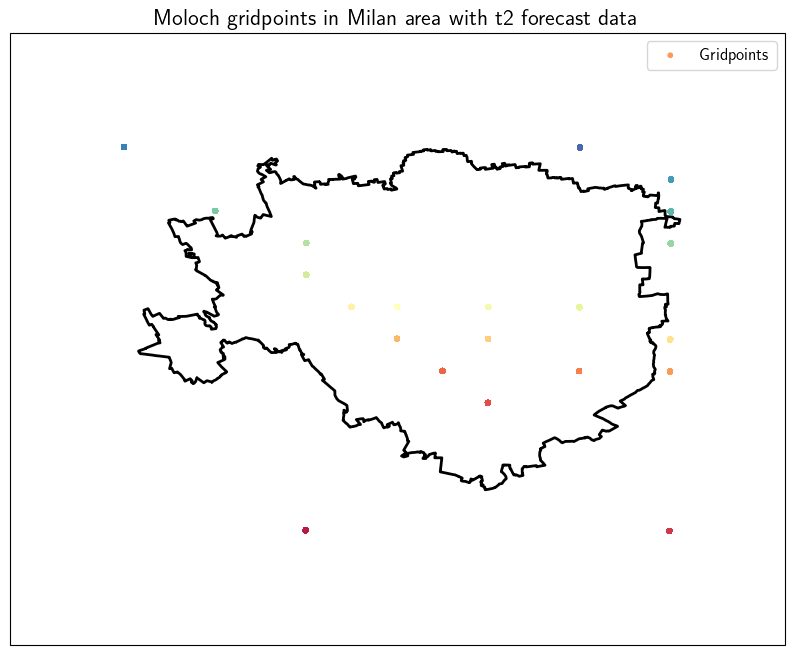

Number of gridpoints: 21


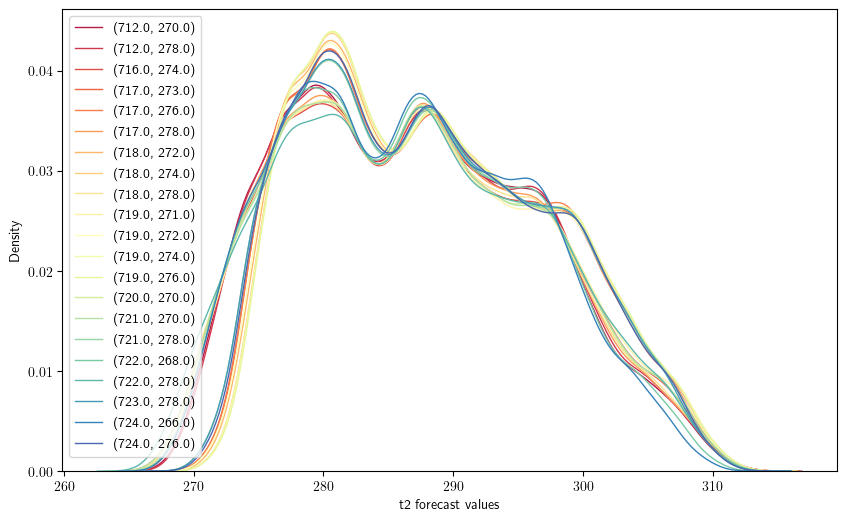

In [9]:
plot_distribution_forecast_moloch(forecast_moloch, var='t2')

In [55]:
def download_observations():
    """
    Download observation data from saved CSV files.
    # 1) from Mistral in observation_mistral/observation_milan_{year}.csv # only from 2023-01-01
    1) from ARPA Lombardia .csv (8 stations)
    2) from FOMD data_fomd/Dati2021-2024/Dati2021-2024 (9 stations)
    """
   
   # ----------------- Mistral downloaded -----------------
    # i=0
    # for year in range(2020,2025):
    #     filename = f'observation_mistral/observation_milan_{year}.csv'
    #     if os.path.exists(filename):
    #         print(f"Loading data from {filename}")
    #         data = pd.read_csv(filename, parse_dates=['REF_TIME'])
    #         if i==0:
    #             all_data= data.copy()
    #         else:
    #             all_data = pd.concat([all_data, data], ignore_index=True)
    #         i+=1

    # # format the columns
    # all_data['REF_TIME'] = pd.to_datetime(all_data['REF_TIME'], utc=True)

    # ----------------- ARPA Lombardia downloaded -----------------

    stations_arpa_altitude= {
        'Milano_vBrera': 122.0,
        'Milano_vFeltre':127.0,
        'Milano_vJuvara':122.0,
        'Milano_vMarche':129.0,
        'Milanno_Lambrate':120.0,
        'Milano_pzza_Zavattari':122.0,
        'Rho_Scalo_Fiorenza_Prato':143.0,
        'Corsico_vle_Italia':119.0
    }
    years = [2021, 2022, 2023, 2024]

    # open one of the files of Mistral to get the lat and lon of the stations
    filename = 'observation_mistral/observation_milan_2023.csv'
    data = pd.read_csv(filename, parse_dates=['REF_TIME'])
    lat_lon = data[['STATION_NAME', 'LATITUDE', 'LONGITUDE', 'ALTITUDE', 'PROVIDER_ID']].drop_duplicates()

    # load the ARPA Lombardia data
    path = 'observation_arpa'
    list_files = [f for f in os.listdir(path) if f.endswith('.csv')]

    all_data = pd.DataFrame()

    for i, station in enumerate(stations_arpa_altitude.keys()):
        data_one_station = pd.DataFrame()

        station_name_latlon = difflib.get_close_matches(station.replace('_', ' '), lat_lon['STATION_NAME'], n=1)[0]

        # find the files that contains the station name
        if station == 'Milano_vBrera': # all years in one file
            files_one_station = [f'temp_{station}_20210101_20241231.csv']
        else:
            files_one_station = difflib.get_close_matches(station + '.csv', list_files, n=len(years))

        # if the station name is found, load the data
        if files_one_station:
            for file in files_one_station:
                data = pd.read_csv(os.path.join(path, file))
                # parse the Data-Ora column to datetime, localize to UTC+1, and convert to UTC
                data['REF_TIME'] = pd.to_datetime(data['Data-Ora'], utc=True) - pd.Timedelta(hours=1)
                # drop the original Data-Ora column
                data = data.drop(columns=['Data-Ora'])

                # append the data to the data_one_station DataFrame
                if data_one_station.empty:
                    data_one_station = data.copy()
                else:
                    data_one_station = pd.concat([data_one_station, data], ignore_index=True)
        else:
            print(f"File for station {station} not found, skipping.")
            continue

        # rename the columns
        data_one_station = data_one_station.rename(columns={
            ' Medio': 'VALUE'
        })

        # drop Id Sensore
        data_one_station = data_one_station.drop(columns=['Id Sensore'])

        # add the station name
        data_one_station['STATION_NAME'] = station_name_latlon

        # add the latitude, longitude, altitude and provider id and id_consuntivo
        data_one_station['PROVIDER_ID'] = 'ARPA'
        data_one_station['LATITUDE'] = lat_lon[lat_lon['STATION_NAME'] == data_one_station['STATION_NAME'].iloc[0]]['LATITUDE'].values[0]
        data_one_station['LONGITUDE'] = lat_lon[lat_lon['STATION_NAME'] == data_one_station['STATION_NAME'].iloc[0]]['LONGITUDE'].values[0]
        data_one_station['ALTITUDE'] = stations_arpa_altitude[station]

        # convert the value to Kelvin
        with pd.option_context('future.no_silent_downcasting', True): # remove the downcasting from pd.replace
            data_one_station['VALUE'] = data_one_station['VALUE'].replace('nd', np.nan).astype(float) + 273.15
            # replace -999 with np.nan
            data_one_station['VALUE'] = data_one_station['VALUE'].replace(-999, np.nan)

        # add to the dataset
        if i==0: 
            all_data = data_one_station.copy()
        else:
            all_data = pd.concat([all_data, data_one_station], ignore_index=True)               

    #  -------------------  FOMD ----------------------

    path=r"data_fomd\Dati2021-2024\Dati2021-2024"
    var= 'Tmed_V'

    codice_stazione = {
        "MILANO Centro": 1,
        "MILANO Bicocca": 2,
        "MILANO Bovisa": 4,
        "MILANO Sarpi": 5,
        "MILANO Città Studi": 6,
        "MILANO Bocconi": 7,
        "MILANO Sud": 8,
        "MILANO Forze Armate": 9,
        "MILANO San Siro": 10
        }
    
    list_files=[f for f in os.listdir(path) if 'Milano' in f]
    list_names = codice_stazione.keys()

    metadata = pd.read_excel(r'data_fomd\Dati2021-2024\Dati2021-2024\Metadata.xlsx', nrows=8)


    for i, name in enumerate(list_names):
        # find closest string name in list_files
        f = difflib.get_close_matches('Milano_'+'_'.join(name.split(' ')[1:])+'.xlsx', list_files)[0]

        # variable name
        varname = str(codice_stazione[name])+'_'+var
        sheetname = ' '.join(name.split(' ')[1:]) 
   
        filename=os.path.join(path, f)
        first_line=pd.read_excel(filename, header=None, nrows=1).values.flatten()  

        data=pd.read_excel(filename, sheet_name=sheetname, names=first_line, usecols=['timestamp', varname])

        # timestamp as datetime, localize, convert to UTC and keep only the dates in the list
        data['timestamp']=pd.to_datetime(data['timestamp'])
        data['timestamp'] = data['timestamp']-pd.Timedelta(hours=1) # convert to UTC, but by hand as the data are in CET and not CEST
        data['timestamp'] = data['timestamp'].dt.tz_localize('UTC')

        # add the station name, and id_consuntivo
        data['ID_CONSUNTIVO']=600000+codice_stazione[name]
        data['STATION_NAME']=name

        # lat and lon and altitude from the metadata, first 8 lines only
        closest_station_name = difflib.get_close_matches(name, metadata['Nome stazione'])[0]
        data['LATITUDE'] = metadata[metadata['Nome stazione'] == closest_station_name].iloc[0]['Latitudine  (gradi decimali WGS84)']
        data['LONGITUDE'] = metadata[metadata['Nome stazione'] == closest_station_name].iloc[0]['Longitudine  (gradi decimali WGS84)']
        data['ALTITUDE'] = metadata[metadata['Nome stazione'] == closest_station_name].iloc[0]['Altezza Totale (m) **']     

        # convert nd to np.nan and value to kelvin
        with pd.option_context('future.no_silent_downcasting', True): # remove the downcasting from pd.replace
            data['VALUE'] = data[varname].replace('nd', np.nan).astype(float) + 273.15
        # drop the original variable column
        data = data.drop(columns=[varname])

        # rename columns
        data=data.rename(columns={'timestamp':'REF_TIME'})

        # add columns provider
        data['PROVIDER_ID'] = 'FOMD'

        # append to the dataset
        if i==0:
            data_all_stations=data
        else:
            data_all_stations=pd.concat([data_all_stations, data], ignore_index=True)

    # merge the two datasets
    all_data = pd.concat([all_data, data_all_stations], ignore_index=True)

    return all_data

In [56]:
temp_obs = download_observations()

In [62]:
temp_obs.head()

,VALUE,REF_TIME,STATION_NAME,PROVIDER_ID,LATITUDE,LONGITUDE,ALTITUDE,ID_CONSUNTIVO
0,275.85,2020-12-31 23:00:00+00:00,Milano v.Brera,ARPA,45.47166,9.18911,122.0,NaN
1,276.15,2021-01-01 00:00:00+00:00,Milano v.Brera,ARPA,45.47166,9.18911,122.0,NaN
2,276.35,2021-01-01 01:00:00+00:00,Milano v.Brera,ARPA,45.47166,9.18911,122.0,NaN
3,276.85,2021-01-01 02:00:00+00:00,Milano v.Brera,ARPA,45.47166,9.18911,122.0,NaN
4,277.25,2021-01-01 03:00:00+00:00,Milano v.Brera,ARPA,45.47166,9.18911,122.0,NaN


In [58]:
def plot_temperature_stations(temp_obs):
    """
    Plot the temperature observation stations on a map of Milan
    
    Parameters
    ----------
    temp_obs: the dataset with temperature observations
    """

    # Get unique stations with their coordinates
    stations = temp_obs[['STATION_NAME', 'LATITUDE', 'LONGITUDE']].drop_duplicates()
    
    # Create color palette for stations
    colorlist = sns.color_palette("Spectral", len(stations))
    colordict = {station: color for station, color in zip(stations['STATION_NAME'], colorlist)}
    stations['COLOR'] = stations['STATION_NAME'].map(colordict)

    # Create map
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([stations['LONGITUDE'].min()-0.05, stations['LONGITUDE'].max()+0.05,
                   stations['LATITUDE'].min()-0.05, stations['LATITUDE'].max()+0.05], crs=ccrs.PlateCarree())

    # Plot the contour of the Comune di Milano
    milano_shp = shapereader.Reader("shapefiles/L090102_ComuneMilano.shp")
    milano_geom = [record.geometry for record in milano_shp.records()]
    milano_gdf = gpd.GeoDataFrame(geometry=milano_geom, crs='EPSG:3003')  # Roma40 Gauss-Boaga
    milano_gdf = milano_gdf.to_crs(epsg=4326)  # Convert to WGS84
    for geom in milano_gdf.geometry:
        ax.add_geometries([geom], crs=ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=2)

    # Plot stations
    ax.set_title('Temperature Observation Stations in Milan', fontsize=16)
    for _, station in stations.iterrows():
        ax.scatter(station['LONGITUDE'], station['LATITUDE'], 
                   c=[station['COLOR']], s=100, transform=ccrs.PlateCarree(), 
                   label=station['STATION_NAME'], marker='o')
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()
    plt.close()

    # Plot distribution of temperature values for each station
    plt.figure(figsize=(12, 6))
    print(f'Number of stations: {len(stations)}')
    
    for station_name in stations['STATION_NAME']:
        station_data = temp_obs[temp_obs['STATION_NAME'] == station_name]
        if len(station_data) > 0:
            sns.kdeplot(station_data['VALUE'].dropna(), label=station_name, 
                       fill=False, alpha=1, color=colordict[station_name], lw=1.5)
    
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Density')
    plt.title('Temperature Distribution by Station')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Plot data availability as timeseries for each station
    plt.figure(figsize=(14, 8))
    
    # Group by station and resample by day to check availability
    for i, station_name in enumerate(stations['STATION_NAME']):
        station_data = temp_obs[temp_obs['STATION_NAME'] == station_name].copy()
        if len(station_data) > 0:
            # Set REF_TIME as index and resample by day
            station_data.set_index('REF_TIME', inplace=True)
            daily_counts = station_data.resample('D').count()['VALUE']
            
            # Create availability mask (1 if data available, 0 if not)
            availability = (daily_counts > 0).astype(int)
            
            # Plot as horizontal lines
            y_pos = i
            for date, avail in availability.items():
                if avail == 1:
                    plt.plot([date, date + pd.Timedelta(days=1)], [y_pos, y_pos], 
                            color=colordict[station_name], linewidth=3, alpha=0.8)
    
    plt.yticks(range(len(stations)), stations['STATION_NAME'])
    plt.xlabel('Date')
    plt.ylabel('Station')
    plt.title('Data Availability Timeline by Station')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



In [59]:
print(temp_obs['VALUE'].describe())

count    583044.000000
mean        286.457594
std          51.426622
min        -725.850000
25%         281.850000
50%         288.450000
75%         295.850000
max         312.750000
Name: VALUE, dtype: float64


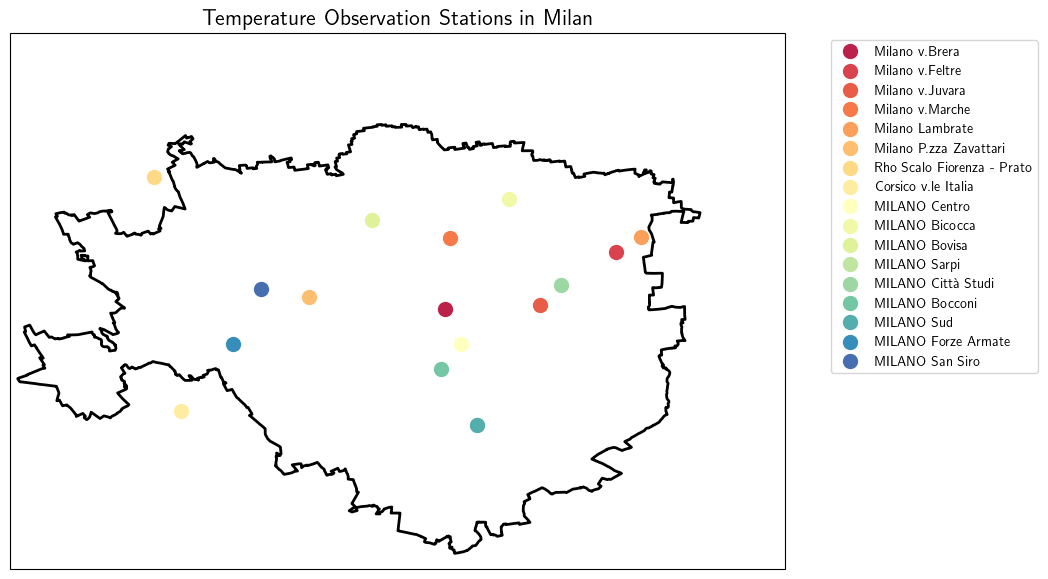

Number of stations: 17


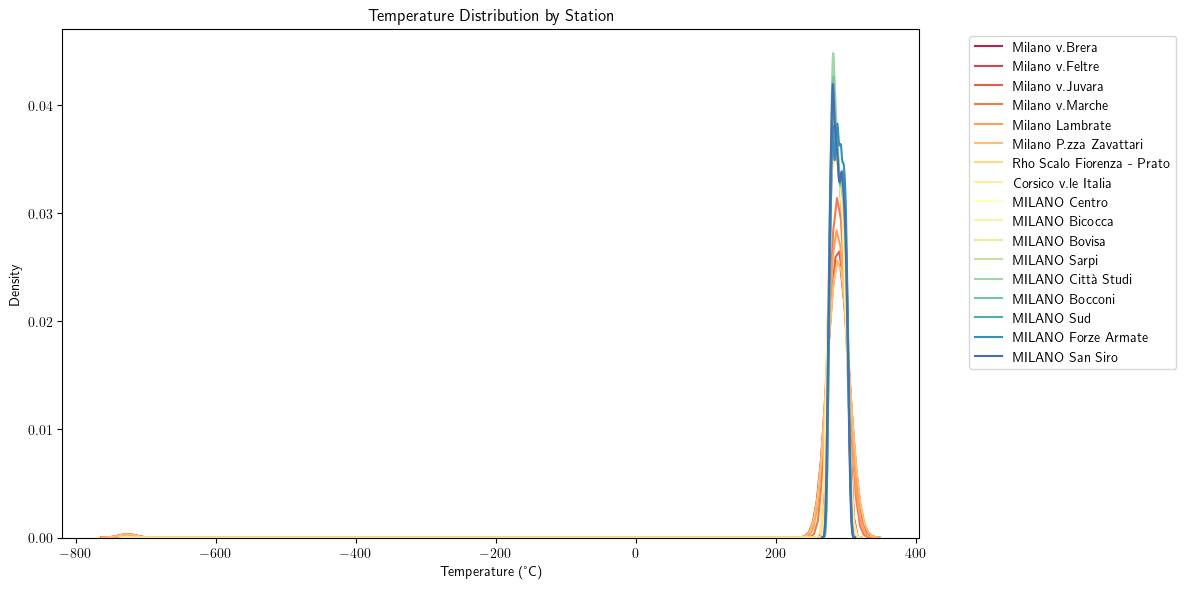

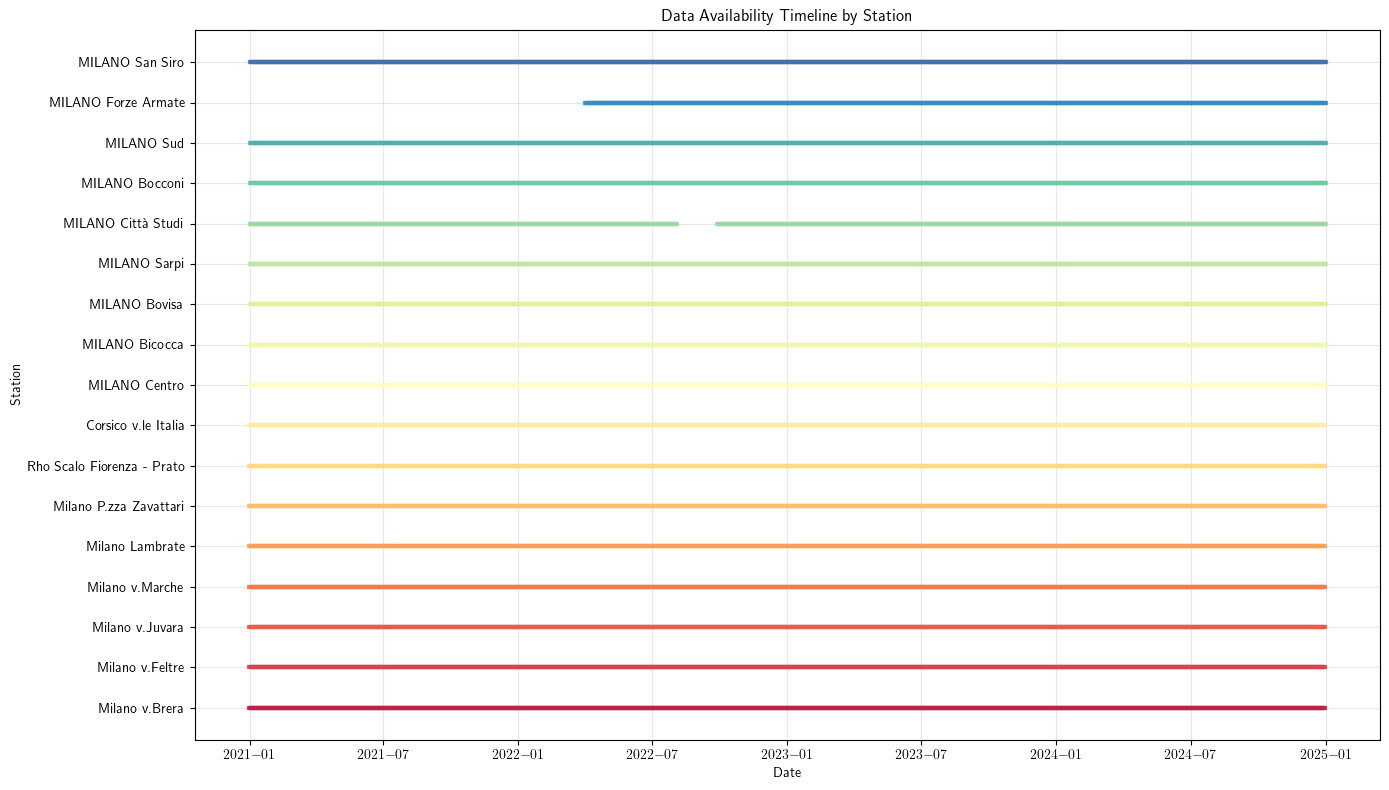

In [60]:
plot_temperature_stations(temp_obs)

In [66]:
def filter_obs(temp_obs):
    """
    Filter the observations to keep only good quality data.
    
    Parameters
    ----------
    temp_obs: the dataset with temperature observations
    
    Returns
    -------
    pandas.DataFrame
        
    """

    # REPLACE low values with NaN
    temp_obs['VALUE'] = temp_obs['VALUE'].where(temp_obs['VALUE'] > 240, np.nan)

    # replace the 257.05 for v.Brera the 2024-07-17
    # date_to_replace = pd.to_datetime('2023-04-17 12:00:00', utc=True)
    # temp_obs.loc[(temp_obs['STATION_NAME'] == 'Milano v.Brera') & 
    #              (temp_obs['REF_TIME'] == date_to_replace), 'VALUE'] = np.nan

    return temp_obs

In [67]:
temp_obs_filtered = filter_obs(temp_obs)

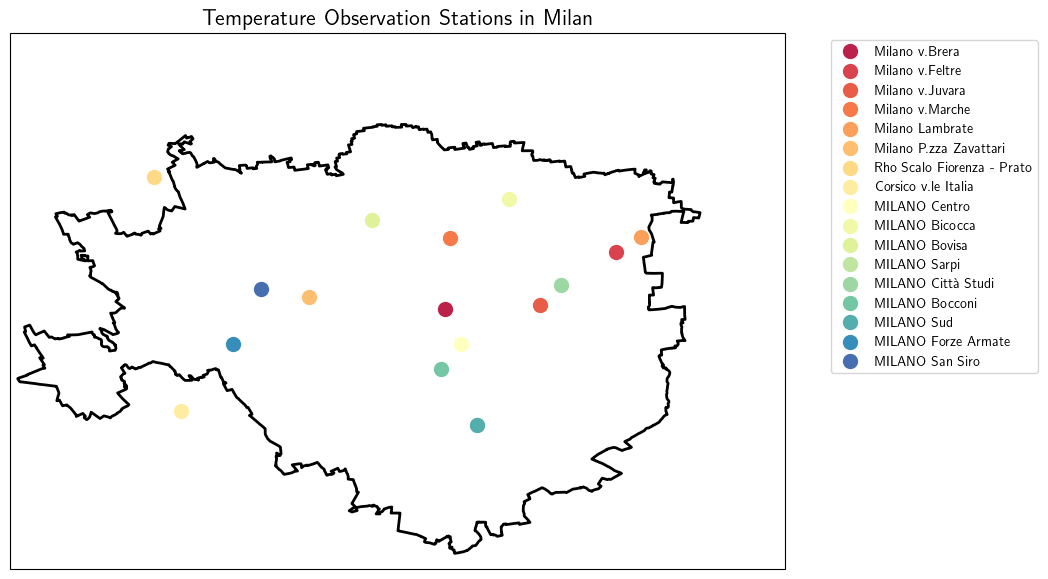

Number of stations: 17


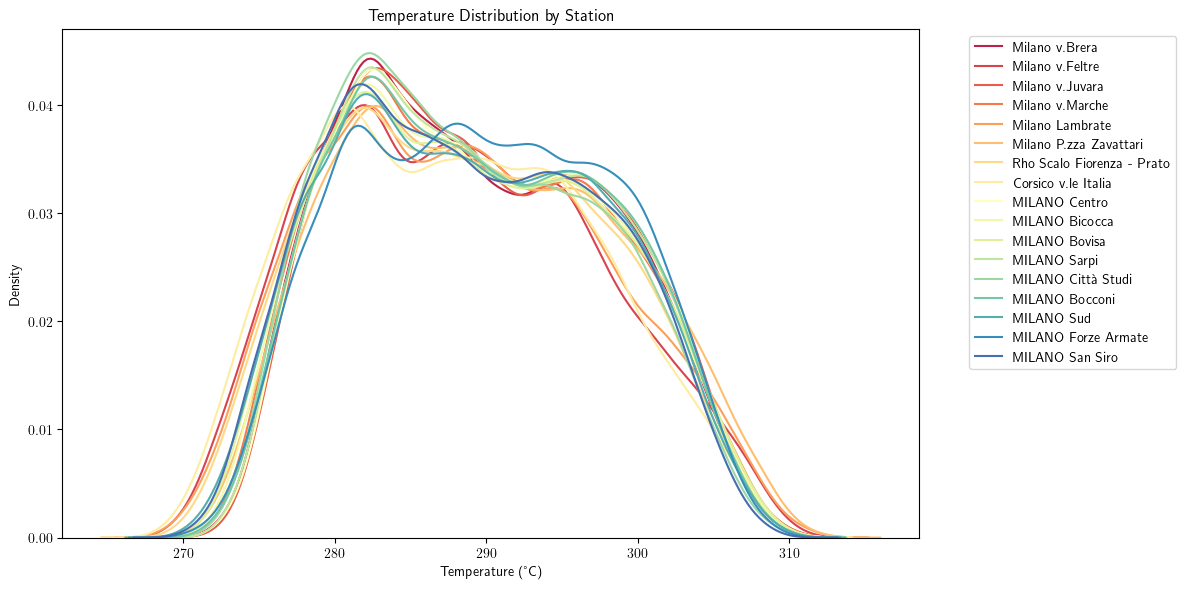

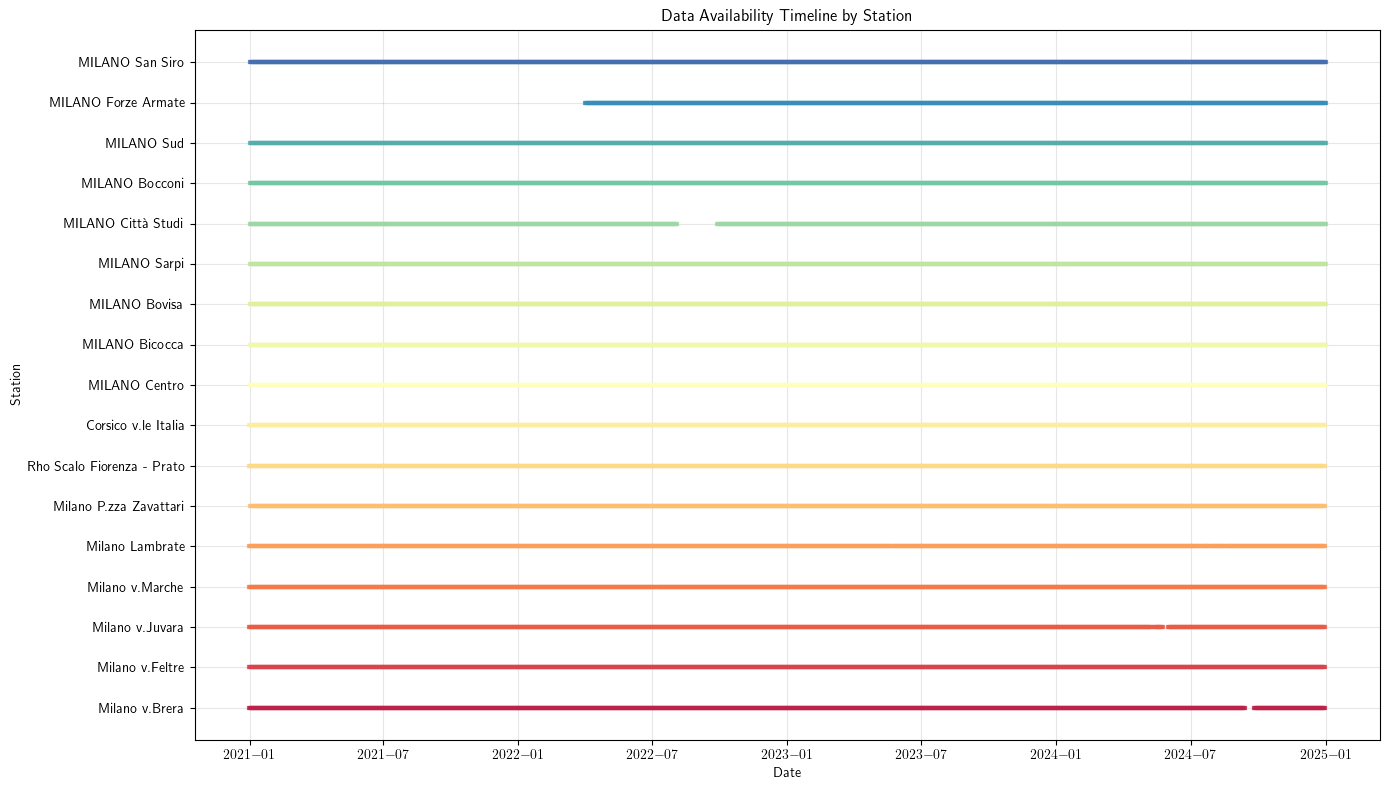

In [68]:
plot_temperature_stations(temp_obs_filtered)

## Model Skill Evaluation Techniques

This section implements various techniques to evaluate the skill of the Moloch regional model against observations, considering spatial location, altitude effects, and different aspects of temperature forecast quality.

In [69]:
def prepare_forecast_observation_pairs(forecast_moloch, temp_obs_filtered):
    """
    Match forecast and observation data for validation.
    
    Parameters
    ----------
    forecast_moloch: DataFrame with Moloch forecasts
    temp_obs_filtered: DataFrame with filtered observations
    
    Returns
    -------
    DataFrame with matched forecast-observation pairs
    """
    
    # Filter forecasts for temperature (t2)
    forecast_temp = forecast_moloch[forecast_moloch['VAR_NAME'] == 't2'].copy()
    
    # Prepare observations
    obs_temp = temp_obs_filtered.copy()
    
    # Add station matching info - use closest gridpoint to each station
    obs_stations = obs_temp[['STATION_NAME', 'LATITUDE', 'LONGITUDE', 'ALTITUDE']].drop_duplicates()
    
    matched_pairs = []
    
    for _, station in obs_stations.iterrows():
        # Find closest gridpoint to this station
        forecast_points = forecast_temp[['X', 'Y', 'LAT', 'LON']].drop_duplicates()
        
        distances = []
        for _, point in forecast_points.iterrows():
            dist = geodesic((station['LATITUDE'], station['LONGITUDE']), 
                          (point['LAT'], point['LON'])).kilometers
            distances.append(dist)
        
        closest_idx = np.argmin(distances)
        closest_point = forecast_points.iloc[closest_idx]
        
        # Get forecasts for this point
        point_forecasts = forecast_temp[
            (forecast_temp['X'] == closest_point['X']) & 
            (forecast_temp['Y'] == closest_point['Y'])
        ].copy()
        
        # Get observations for this station
        station_obs = obs_temp[obs_temp['STATION_NAME'] == station['STATION_NAME']].copy()
        
        # Merge on time
        merged = pd.merge(point_forecasts, station_obs, 
                         left_on='TIME', right_on='REF_TIME', how='inner')
        
        if len(merged) > 0:
            merged['STATION_NAME'] = station['STATION_NAME']
            merged['DISTANCE_KM'] = distances[closest_idx]
            merged['ALTITUDE_DIFF'] = merged['ALTITUDE'] - 122  # Approximate model elevation
            matched_pairs.append(merged)
    
    if matched_pairs:
        return pd.concat(matched_pairs, ignore_index=True)
    else:
        return pd.DataFrame()

# Prepare the matched dataset
print("Preparing forecast-observation pairs...")
matched_data = prepare_forecast_observation_pairs(forecast_moloch, temp_obs_filtered)
print(f"Created {len(matched_data)} matched forecast-observation pairs")
print(f"Covering {matched_data['STATION_NAME'].nunique()} stations")

Preparing forecast-observation pairs...
Created 2310069 matched forecast-observation pairs
Covering 17 stations
Created 2310069 matched forecast-observation pairs
Covering 17 stations


In [70]:
def calculate_statistical_metrics(matched_data):
    """
    Calculate comprehensive statistical metrics for model evaluation.
    
    Parameters
    ----------
    matched_data: DataFrame with matched forecast-observation pairs
    
    Returns
    -------
    DataFrame with metrics for each station
    """
    
    metrics_list = []
    
    for station in matched_data['STATION_NAME'].unique():
        station_data = matched_data[matched_data['STATION_NAME'] == station].copy()
        
        if len(station_data) < 10:  # Skip stations with too few data points
            continue
            
        forecast = station_data['VALUE_x']  # Forecast values
        observed = station_data['VALUE_y']  # Observed values
        
        # Remove NaN pairs
        valid_mask = ~(np.isnan(forecast) | np.isnan(observed))
        forecast_clean = forecast[valid_mask]
        observed_clean = observed[valid_mask]
        
        if len(forecast_clean) < 10:
            continue
        
        # Basic statistics
        n_points = len(forecast_clean)
        mean_obs = np.mean(observed_clean)
        mean_forecast = np.mean(forecast_clean)
        
        # Error metrics
        bias = np.mean(forecast_clean - observed_clean)
        mae = np.mean(np.abs(forecast_clean - observed_clean))
        rmse = np.sqrt(np.mean((forecast_clean - observed_clean)**2))
        mape = np.mean(np.abs((forecast_clean - observed_clean) / observed_clean)) * 100
        
        # Correlation
        pearson_r, pearson_p = pearsonr(forecast_clean, observed_clean)
        spearman_r, spearman_p = spearmanr(forecast_clean, observed_clean)
        
        # Linear regression
        slope, intercept, r_value, p_value, std_err = linregress(observed_clean, forecast_clean)
        
        # Normalized metrics
        normalized_bias = bias / mean_obs
        normalized_rmse = rmse / mean_obs
        
        # Skill scores
        # Nash-Sutcliffe Efficiency
        nse = 1 - (np.sum((observed_clean - forecast_clean)**2) / 
                   np.sum((observed_clean - mean_obs)**2))
        
        # Index of Agreement (Willmott)
        ioa = 1 - (np.sum((observed_clean - forecast_clean)**2) / 
                   np.sum((np.abs(forecast_clean - mean_obs) + 
                          np.abs(observed_clean - mean_obs))**2))
        
        # Temperature-specific metrics
        # Seasonal bias (if data spans multiple seasons)
        station_data['MONTH'] = pd.to_datetime(station_data['TIME']).dt.month
        seasonal_bias = {}
        for season, months in [('Winter', [12, 1, 2]), ('Spring', [3, 4, 5]), 
                              ('Summer', [6, 7, 8]), ('Autumn', [9, 10, 11])]:
            season_data = station_data[station_data['MONTH'].isin(months)]
            if len(season_data) > 5:
                seasonal_bias[season] = np.mean(season_data['VALUE_x'] - season_data['VALUE_y'])
        
        # Altitude and distance info
        altitude = station_data['ALTITUDE'].iloc[0]
        altitude_diff = station_data['ALTITUDE_DIFF'].iloc[0] 
        distance_km = station_data['DISTANCE_KM'].iloc[0]
        
        metrics = {
            'STATION_NAME': station,
            'N_POINTS': n_points,
            'DISTANCE_KM': distance_km,
            'ALTITUDE': altitude,
            'ALTITUDE_DIFF': altitude_diff,
            'MEAN_OBS': mean_obs,
            'MEAN_FORECAST': mean_forecast,
            'BIAS': bias,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'NORMALIZED_BIAS': normalized_bias,
            'NORMALIZED_RMSE': normalized_rmse,
            'PEARSON_R': pearson_r,
            'PEARSON_P': pearson_p,
            'SPEARMAN_R': spearman_r,
            'REGRESSION_SLOPE': slope,
            'REGRESSION_INTERCEPT': intercept,
            'R_SQUARED': r_value**2,
            'NSE': nse,
            'IOA': ioa
        }
        
        # Add seasonal bias
        for season in seasonal_bias:
            metrics[f'BIAS_{season.upper()}'] = seasonal_bias[season]
        
        metrics_list.append(metrics)
    
    return pd.DataFrame(metrics_list)

# Calculate metrics
print("Calculating statistical metrics...")
station_metrics = calculate_statistical_metrics(matched_data)
print(f"Calculated metrics for {len(station_metrics)} stations")
station_metrics

Calculating statistical metrics...
Calculated metrics for 17 stations
Calculated metrics for 17 stations


,STATION_NAME,N_POINTS,DISTANCE_KM,ALTITUDE,ALTITUDE_DIFF,MEAN_OBS,MEAN_FORECAST,BIAS,MAE,RMSE,...,SPEARMAN_R,REGRESSION_SLOPE,REGRESSION_INTERCEPT,R_SQUARED,NSE,IOA,BIAS_WINTER,BIAS_SPRING,BIAS_SUMMER,BIAS_AUTUMN
0,Milano v.Brera,134564,0.653733,122.0,0.0,288.843746,288.476394,-0.367353,1.544795,1.973220,...,0.981275,1.096497,-28.239942,0.963019,0.942527,0.987073,-1.577971,0.069326,0.955913,-0.716326
1,Milano v.Feltre,136868,1.995298,127.0,5.0,287.698694,288.212107,0.513412,1.576187,2.044984,...,0.978970,1.037247,-10.202567,0.955854,0.945487,0.987041,-0.526387,0.786307,1.486904,0.442136
2,Milano v.Juvara,134649,1.152847,122.0,0.0,288.974154,288.503215,-0.470939,1.553774,1.976602,...,0.981553,1.095851,-28.169388,0.963264,0.941706,0.986884,-1.674020,-0.087261,0.865005,-0.760305
3,Milano v.Marche,136553,3.284064,129.0,7.0,288.728180,288.535243,-0.192937,1.418463,1.827913,...,0.982954,1.079118,-23.036645,0.965444,0.951519,0.988899,-1.233446,0.116928,0.927782,-0.409222
4,Milano Lambrate,135393,1.300940,120.0,-2.0,287.960546,288.091425,0.130879,1.553931,2.020059,...,0.976744,1.029392,-8.332868,0.953177,0.946859,0.987269,-0.952844,0.475612,1.119609,0.060234
5,Milano P.zza Zavattari,136078,1.182261,122.0,0.0,289.123021,287.045869,-2.077153,2.469766,3.012297,...,0.978155,1.092787,-28.903996,0.956591,0.880269,0.973386,-3.371448,-1.749517,-0.791810,-2.207578
6,Rho Scalo Fiorenza - Prato,136892,1.453128,143.0,21.0,288.038559,286.657670,-1.380889,1.937038,2.425518,...,0.979174,1.059490,-18.516327,0.957156,0.920421,0.981589,-2.329040,-1.058291,-0.484894,-1.512527
7,Corsico v.le Italia,136790,4.465002,119.0,-3.0,287.241471,287.054325,-0.187146,1.644516,2.142130,...,0.980064,1.097884,-28.303522,0.959515,0.939096,0.986330,-1.396508,0.053390,1.234579,-0.443108
8,MILANO Centro,137404,0.759584,135.0,13.0,289.071901,288.499001,-0.572900,1.584549,1.999937,...,0.981651,1.094915,-28.010220,0.963245,0.940351,0.986571,-1.760724,-0.167364,0.717680,-0.861003
9,MILANO Bicocca,137380,3.441113,142.6,20.6,288.626120,288.139850,-0.486269,1.492807,1.907141,...,0.982613,1.077520,-22.860651,0.964736,0.948182,0.988127,-1.584666,-0.055274,0.630000,-0.735898


Creating Taylor diagram...


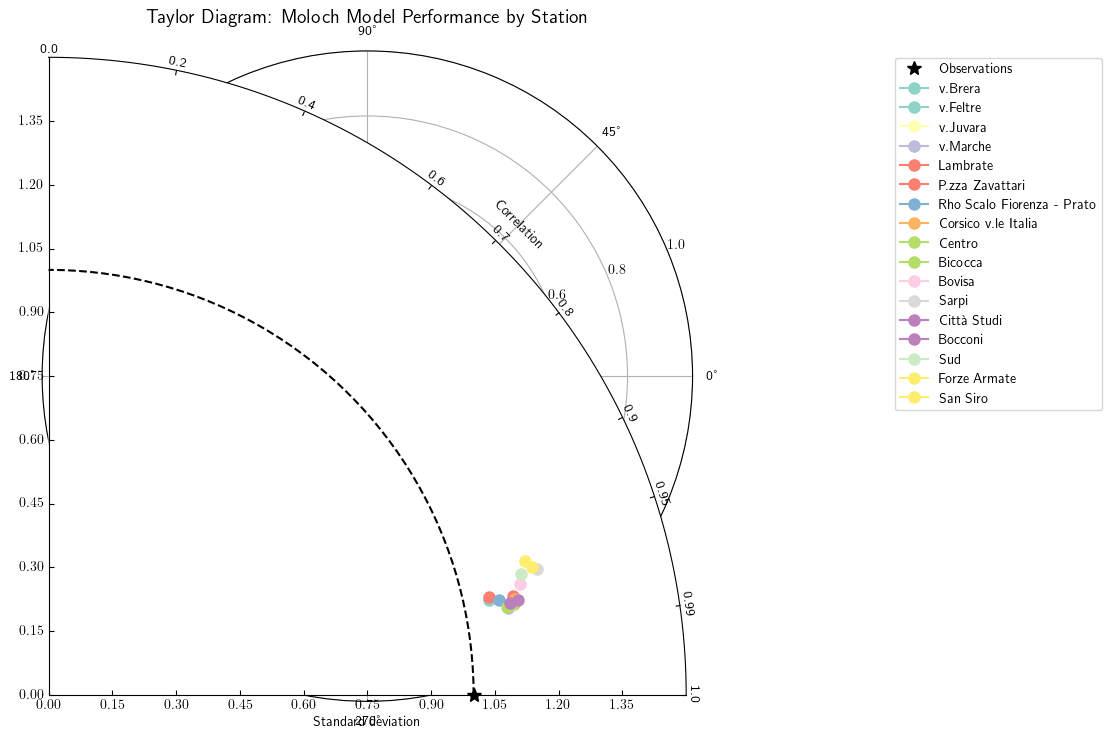

In [71]:
def create_taylor_diagram(matched_data, station_metrics):
    """
    Create Taylor diagram to visualize model performance across stations.
    
    Parameters
    ----------
    matched_data: DataFrame with matched forecast-observation pairs
    station_metrics: DataFrame with calculated metrics per station
    """
    
    fig = plt.figure(figsize=(10, 8))
    
    # Create Taylor diagram
    taylor_ax = fig.add_subplot(111, projection='polar')
    taylor_diagram = TaylorDiagram(refstd=1.0, fig=fig, rect=111, label='Observations')
    
    # Colors for different stations
    colors = plt.cm.Set3(np.linspace(0, 1, len(station_metrics)))
    
    for i, (_, metrics) in enumerate(station_metrics.iterrows()):
        station = metrics['STATION_NAME']
        station_data = matched_data[matched_data['STATION_NAME'] == station]
        
        if len(station_data) < 10:
            continue
            
        forecast = station_data['VALUE_x'].dropna()
        observed = station_data['VALUE_y'].dropna()
        
        # Calculate normalized statistics for Taylor diagram
        std_forecast = np.std(forecast)
        std_observed = np.std(observed)
        correlation = metrics['PEARSON_R']
        
        # Normalize by observed standard deviation
        normalized_std = std_forecast / std_observed if std_observed > 0 else 0
        
        # Add point to Taylor diagram
        taylor_diagram.add_sample(normalized_std, correlation, 
                                marker='o', markersize=8, 
                                label=station.replace('MILANO ', '').replace('Milano ', ''),
                                color=colors[i])
    
    # Add legend
    plt.legend(bbox_to_anchor=(1.3, 1.0), loc='upper left')
    plt.title('Taylor Diagram: Moloch Model Performance by Station', 
              pad=20, fontsize=14)
    
    plt.tight_layout()
    plt.show()

# Create Taylor diagram
print("Creating Taylor diagram...")
create_taylor_diagram(matched_data, station_metrics)

Analyzing spatial performance patterns...


C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_1648\2935050818.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  band_stats = merged_metrics.groupby('ALTITUDE_BAND').agg({


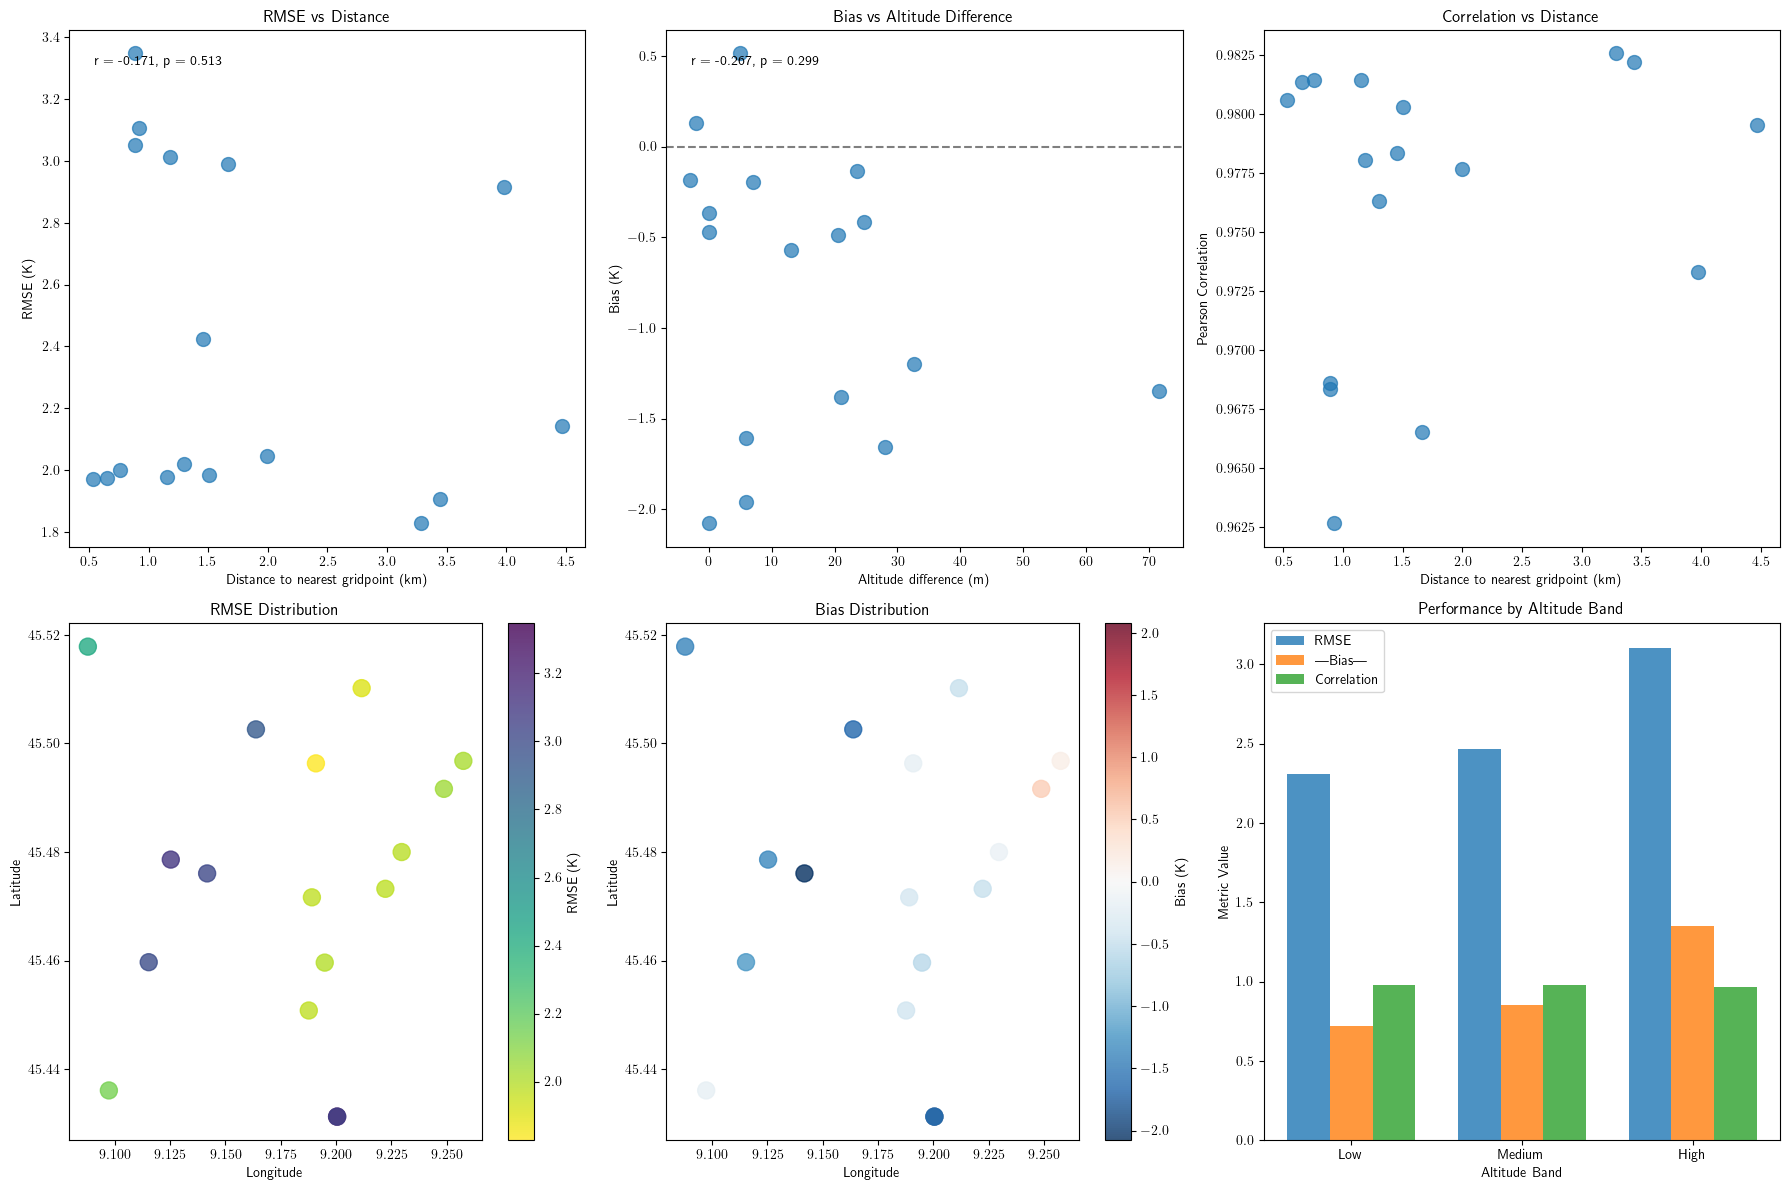

In [72]:
def analyze_spatial_performance(station_metrics):
    """
    Analyze how model performance varies spatially and with altitude.
    
    Parameters
    ----------
    station_metrics: DataFrame with calculated metrics per station
    """
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. RMSE vs Distance from model gridpoint
    axes[0, 0].scatter(station_metrics['DISTANCE_KM'], station_metrics['RMSE'], 
                      alpha=0.7, s=100)
    axes[0, 0].set_xlabel('Distance to nearest gridpoint (km)')
    axes[0, 0].set_ylabel('RMSE (K)')
    axes[0, 0].set_title('RMSE vs Distance')
    
    # Add correlation info
    if len(station_metrics) > 2:
        corr, p_val = pearsonr(station_metrics['DISTANCE_KM'], station_metrics['RMSE'])
        axes[0, 0].text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
                       transform=axes[0, 0].transAxes, verticalalignment='top')
    
    # 2. Bias vs Altitude difference
    axes[0, 1].scatter(station_metrics['ALTITUDE_DIFF'], station_metrics['BIAS'], 
                      alpha=0.7, s=100)
    axes[0, 1].set_xlabel('Altitude difference (m)')
    axes[0, 1].set_ylabel('Bias (K)')
    axes[0, 1].set_title('Bias vs Altitude Difference')
    axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    if len(station_metrics) > 2:
        corr, p_val = pearsonr(station_metrics['ALTITUDE_DIFF'], station_metrics['BIAS'])
        axes[0, 1].text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
                       transform=axes[0, 1].transAxes, verticalalignment='top')
    
    # 3. Correlation vs Distance
    axes[0, 2].scatter(station_metrics['DISTANCE_KM'], station_metrics['PEARSON_R'], 
                      alpha=0.7, s=100)
    axes[0, 2].set_xlabel('Distance to nearest gridpoint (km)')
    axes[0, 2].set_ylabel('Pearson Correlation')
    axes[0, 2].set_title('Correlation vs Distance')
    
    # 4. Map of RMSE
    # Get unique stations with coordinates
    stations_with_coords = matched_data[['STATION_NAME', 'LATITUDE', 'LONGITUDE']].drop_duplicates()
    merged_metrics = station_metrics.merge(stations_with_coords, on='STATION_NAME')
    
    ax4 = axes[1, 0]
    scatter = ax4.scatter(merged_metrics['LONGITUDE'], merged_metrics['LATITUDE'], 
                         c=merged_metrics['RMSE'], s=150, cmap='viridis_r', alpha=0.8)
    ax4.set_xlabel('Longitude')
    ax4.set_ylabel('Latitude')
    ax4.set_title('RMSE Distribution')
    plt.colorbar(scatter, ax=ax4, label='RMSE (K)')
    
    # 5. Map of Bias
    ax5 = axes[1, 1]
    scatter2 = ax5.scatter(merged_metrics['LONGITUDE'], merged_metrics['LATITUDE'], 
                          c=merged_metrics['BIAS'], s=150, cmap='RdBu_r', alpha=0.8,
                          vmin=-merged_metrics['BIAS'].abs().max(), 
                          vmax=merged_metrics['BIAS'].abs().max())
    ax5.set_xlabel('Longitude')
    ax5.set_ylabel('Latitude')
    ax5.set_title('Bias Distribution')
    plt.colorbar(scatter2, ax=ax5, label='Bias (K)')
    
    # 6. Performance summary by altitude bands
    ax6 = axes[1, 2]
    # Create altitude bands
    altitude_bands = pd.cut(merged_metrics['ALTITUDE'], bins=3, labels=['Low', 'Medium', 'High'])
    merged_metrics['ALTITUDE_BAND'] = altitude_bands
    
    band_stats = merged_metrics.groupby('ALTITUDE_BAND').agg({
        'RMSE': 'mean',
        'BIAS': 'mean',
        'PEARSON_R': 'mean'
    }).reset_index()
    
    x = np.arange(len(band_stats))
    width = 0.25
    
    ax6.bar(x - width, band_stats['RMSE'], width, label='RMSE', alpha=0.8)
    ax6.bar(x, band_stats['BIAS'].abs(), width, label='|Bias|', alpha=0.8)
    ax6.bar(x + width, band_stats['PEARSON_R'], width, label='Correlation', alpha=0.8)
    
    ax6.set_xlabel('Altitude Band')
    ax6.set_ylabel('Metric Value')
    ax6.set_title('Performance by Altitude Band')
    ax6.set_xticks(x)
    ax6.set_xticklabels(band_stats['ALTITUDE_BAND'])
    ax6.legend()
    
    plt.tight_layout()
    plt.show()
    
    return merged_metrics

# Analyze spatial performance
print("Analyzing spatial performance patterns...")
spatial_analysis = analyze_spatial_performance(station_metrics)

Analyzing temporal performance patterns...


AttributeError: 'list' object has no attribute 'map'

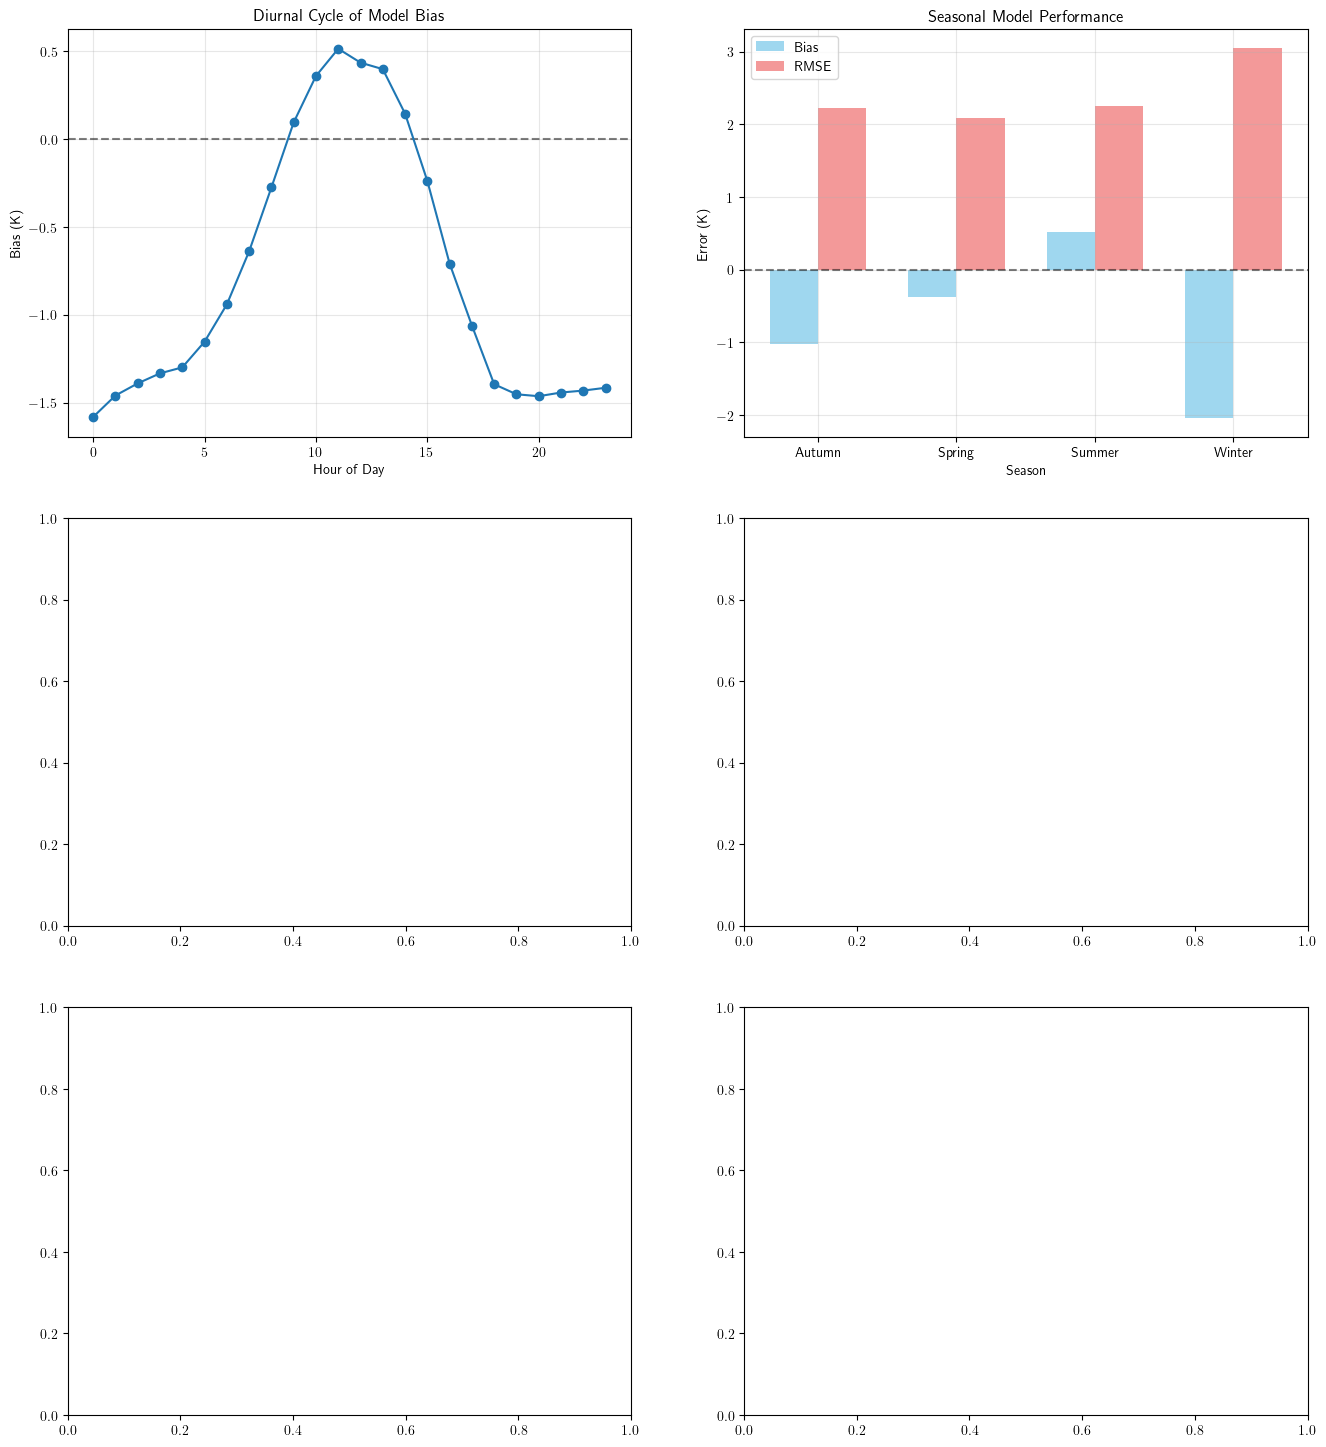

In [73]:
def analyze_temporal_performance(matched_data):
    """
    Analyze how model performance varies temporally.
    
    Parameters
    ----------
    matched_data: DataFrame with matched forecast-observation pairs
    """
    
    # Add time-based columns
    matched_data['DATETIME'] = pd.to_datetime(matched_data['TIME'])
    matched_data['HOUR'] = matched_data['DATETIME'].dt.hour
    matched_data['MONTH'] = matched_data['DATETIME'].dt.month
    matched_data['SEASON'] = matched_data['MONTH'].map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
    })
    matched_data['ERROR'] = matched_data['VALUE_x'] - matched_data['VALUE_y']
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    
    # 1. Diurnal cycle of bias
    hourly_stats = matched_data.groupby('HOUR').agg({
        'ERROR': ['mean', 'std', 'count']
    }).round(3)
    hourly_stats.columns = ['BIAS', 'STD', 'COUNT']
    
    axes[0, 0].errorbar(hourly_stats.index, hourly_stats['BIAS'], 
                       yerr=hourly_stats['STD']/np.sqrt(hourly_stats['COUNT']), 
                       marker='o', capsize=3)
    axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[0, 0].set_xlabel('Hour of Day')
    axes[0, 0].set_ylabel('Bias (K)')
    axes[0, 0].set_title('Diurnal Cycle of Model Bias')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Seasonal performance
    seasonal_stats = matched_data.groupby('SEASON').agg({
        'ERROR': ['mean', lambda x: np.sqrt(np.mean(x**2)), 'std', 'count']
    }).round(3)
    seasonal_stats.columns = ['BIAS', 'RMSE', 'STD', 'COUNT']
    
    x = np.arange(len(seasonal_stats))
    width = 0.35
    
    axes[0, 1].bar(x - width/2, seasonal_stats['BIAS'], width, 
                  label='Bias', alpha=0.8, color='skyblue')
    axes[0, 1].bar(x + width/2, seasonal_stats['RMSE'], width, 
                  label='RMSE', alpha=0.8, color='lightcoral')
    axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[0, 1].set_xlabel('Season')
    axes[0, 1].set_ylabel('Error (K)')
    axes[0, 1].set_title('Seasonal Model Performance')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(seasonal_stats.index)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Monthly bias evolution
    monthly_bias = matched_data.groupby(['DATETIME'].map(lambda x: x.strftime('%Y-%m')))['ERROR'].mean()
    
    axes[1, 0].plot(range(len(monthly_bias)), monthly_bias.values, marker='o')
    axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[1, 0].set_xlabel('Time Period')
    axes[1, 0].set_ylabel('Monthly Mean Bias (K)')
    axes[1, 0].set_title('Time Evolution of Model Bias')
    axes[1, 0].tick_params(axis='x', rotation=45)
    # Set x-tick labels to show every 6 months
    step = max(1, len(monthly_bias) // 10)
    axes[1, 0].set_xticks(range(0, len(monthly_bias), step))
    axes[1, 0].set_xticklabels(monthly_bias.index[::step], rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Temperature range performance
    # Binning observations into temperature ranges
    matched_data['TEMP_RANGE'] = pd.cut(matched_data['VALUE_y'], 
                                       bins=5, labels=['Very Cold', 'Cold', 'Moderate', 'Warm', 'Hot'])
    
    temp_range_stats = matched_data.groupby('TEMP_RANGE').agg({
        'ERROR': ['mean', lambda x: np.sqrt(np.mean(x**2)), 'count']
    }).round(3)
    temp_range_stats.columns = ['BIAS', 'RMSE', 'COUNT']
    
    axes[1, 1].bar(temp_range_stats.index, temp_range_stats['BIAS'], 
                  alpha=0.8, color='lightgreen')
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[1, 1].set_xlabel('Temperature Range')
    axes[1, 1].set_ylabel('Bias (K)')
    axes[1, 1].set_title('Performance by Temperature Range')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3)
    
    # 5. Scatter plot: Forecast vs Observed by season
    seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
    colors = ['blue', 'green', 'red', 'orange']
    
    for season, color in zip(seasons, colors):
        season_data = matched_data[matched_data['SEASON'] == season]
        if len(season_data) > 0:
            axes[2, 0].scatter(season_data['VALUE_y'], season_data['VALUE_x'], 
                             alpha=0.3, s=1, color=color, label=season)
    
    # Add 1:1 line
    min_val = min(matched_data['VALUE_y'].min(), matched_data['VALUE_x'].min())
    max_val = max(matched_data['VALUE_y'].max(), matched_data['VALUE_x'].max())
    axes[2, 0].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, linewidth=2)
    
    axes[2, 0].set_xlabel('Observed Temperature (K)')
    axes[2, 0].set_ylabel('Forecast Temperature (K)')
    axes[2, 0].set_title('Forecast vs Observed by Season')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)
    
    # 6. Error distribution by season
    for i, season in enumerate(seasons):
        season_data = matched_data[matched_data['SEASON'] == season]
        if len(season_data) > 0:
            axes[2, 1].hist(season_data['ERROR'], bins=30, alpha=0.5, 
                          label=season, color=colors[i], density=True)
    
    axes[2, 1].axvline(x=0, color='black', linestyle='--', alpha=0.8)
    axes[2, 1].set_xlabel('Forecast Error (K)')
    axes[2, 1].set_ylabel('Density')
    axes[2, 1].set_title('Error Distribution by Season')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\\n=== TEMPORAL PERFORMANCE SUMMARY ===")
    print("\\nHourly Bias Range:")
    print(f"Min: {hourly_stats['BIAS'].min():.3f} K at hour {hourly_stats['BIAS'].idxmin()}")
    print(f"Max: {hourly_stats['BIAS'].max():.3f} K at hour {hourly_stats['BIAS'].idxmax()}")
    
    print("\\nSeasonal Performance:")
    for season in seasonal_stats.index:
        print(f"{season}: Bias = {seasonal_stats.loc[season, 'BIAS']:.3f} K, "
              f"RMSE = {seasonal_stats.loc[season, 'RMSE']:.3f} K")

# Analyze temporal performance
print("Analyzing temporal performance patterns...")
analyze_temporal_performance(matched_data)

In [74]:
def analyze_extreme_events(matched_data):
    """
    Analyze model performance for extreme temperature events.
    
    Parameters
    ----------
    matched_data: DataFrame with matched forecast-observation pairs
    """
    
    # Define extreme thresholds (percentiles of observations)
    obs_temps = matched_data['VALUE_y'].dropna()
    
    cold_threshold = np.percentile(obs_temps, 10)  # 10th percentile
    hot_threshold = np.percentile(obs_temps, 90)   # 90th percentile
    
    # Classify events
    matched_data['EVENT_TYPE'] = 'Normal'
    matched_data.loc[matched_data['VALUE_y'] <= cold_threshold, 'EVENT_TYPE'] = 'Cold Extreme'
    matched_data.loc[matched_data['VALUE_y'] >= hot_threshold, 'EVENT_TYPE'] = 'Hot Extreme'
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Performance by event type
    event_stats = matched_data.groupby('EVENT_TYPE').agg({
        'ERROR': ['mean', lambda x: np.sqrt(np.mean(x**2)), 'std', 'count']
    }).round(3)
    event_stats.columns = ['BIAS', 'RMSE', 'STD', 'COUNT']
    
    x = np.arange(len(event_stats))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, event_stats['BIAS'], width, 
                  label='Bias', alpha=0.8, color='lightblue')
    axes[0, 0].bar(x + width/2, event_stats['RMSE'], width, 
                  label='RMSE', alpha=0.8, color='lightcoral')
    axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[0, 0].set_xlabel('Event Type')
    axes[0, 0].set_ylabel('Error (K)')
    axes[0, 0].set_title('Model Performance by Event Type')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(event_stats.index, rotation=45)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Contingency table for extreme events
    # Binary classification: extreme (hot or cold) vs normal
    matched_data['IS_EXTREME_OBS'] = matched_data['EVENT_TYPE'] != 'Normal'
    matched_data['IS_EXTREME_FCST'] = ((matched_data['VALUE_x'] <= cold_threshold) | 
                                      (matched_data['VALUE_x'] >= hot_threshold))
    
    # Create contingency table
    contingency = pd.crosstab(matched_data['IS_EXTREME_OBS'], 
                             matched_data['IS_EXTREME_FCST'], 
                             margins=True)
    
    # Calculate skill metrics
    tp = contingency.loc[True, True] if True in contingency.index and True in contingency.columns else 0
    fp = contingency.loc[False, True] if False in contingency.index and True in contingency.columns else 0
    fn = contingency.loc[True, False] if True in contingency.index and False in contingency.columns else 0
    tn = contingency.loc[False, False] if False in contingency.index and False in contingency.columns else 0
    
    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    
    # Plot contingency table as heatmap
    sns.heatmap(contingency.iloc[:-1, :-1], annot=True, fmt='d', cmap='Blues', 
                ax=axes[0, 1], cbar_kws={'label': 'Count'})
    axes[0, 1].set_xlabel('Forecast Extreme')
    axes[0, 1].set_ylabel('Observed Extreme')
    axes[0, 1].set_title(f'Extreme Event Detection\\nPrecision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1_score:.3f}')
    
    # 3. Extreme event bias by station
    extreme_by_station = matched_data[matched_data['EVENT_TYPE'] != 'Normal'].groupby('STATION_NAME').agg({
        'ERROR': ['mean', 'count']
    }).round(3)
    extreme_by_station.columns = ['EXTREME_BIAS', 'EXTREME_COUNT']
    
    # Only show stations with sufficient extreme events
    extreme_by_station = extreme_by_station[extreme_by_station['EXTREME_COUNT'] >= 10]
    
    if len(extreme_by_station) > 0:
        axes[1, 0].barh(range(len(extreme_by_station)), extreme_by_station['EXTREME_BIAS'], 
                       alpha=0.8, color='orange')
        axes[1, 0].axvline(x=0, color='black', linestyle='--', alpha=0.5)
        axes[1, 0].set_yticks(range(len(extreme_by_station)))
        axes[1, 0].set_yticklabels([name.replace('MILANO ', '').replace('Milano ', '') 
                                   for name in extreme_by_station.index], fontsize=8)
        axes[1, 0].set_xlabel('Extreme Event Bias (K)')
        axes[1, 0].set_title('Extreme Event Bias by Station')
        axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Forecast vs Observed for extreme events only
    extreme_data = matched_data[matched_data['EVENT_TYPE'] != 'Normal']
    
    colors_map = {'Cold Extreme': 'blue', 'Hot Extreme': 'red'}
    for event_type in ['Cold Extreme', 'Hot Extreme']:
        event_data = extreme_data[extreme_data['EVENT_TYPE'] == event_type]
        if len(event_data) > 0:
            axes[1, 1].scatter(event_data['VALUE_y'], event_data['VALUE_x'], 
                             alpha=0.6, s=20, color=colors_map[event_type], 
                             label=event_type)
    
    # Add 1:1 line and thresholds
    min_val = extreme_data['VALUE_y'].min()
    max_val = extreme_data['VALUE_y'].max()
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, linewidth=2)
    axes[1, 1].axvline(x=cold_threshold, color='blue', linestyle=':', alpha=0.7, label='Cold threshold')
    axes[1, 1].axvline(x=hot_threshold, color='red', linestyle=':', alpha=0.7, label='Hot threshold')
    axes[1, 1].axhline(y=cold_threshold, color='blue', linestyle=':', alpha=0.7)
    axes[1, 1].axhline(y=hot_threshold, color='red', linestyle=':', alpha=0.7)
    
    axes[1, 1].set_xlabel('Observed Temperature (K)')
    axes[1, 1].set_ylabel('Forecast Temperature (K)')
    axes[1, 1].set_title('Extreme Events: Forecast vs Observed')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print extreme event summary
    print("\\n=== EXTREME EVENTS ANALYSIS ===")
    print(f"Cold extreme threshold (10th percentile): {cold_threshold:.2f} K ({cold_threshold-273.15:.2f} °C)")
    print(f"Hot extreme threshold (90th percentile): {hot_threshold:.2f} K ({hot_threshold-273.15:.2f} °C)")
    print(f"\\nExtreme event detection performance:")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1_score:.3f}")
    print(f"Accuracy: {accuracy:.3f}")
    
    return extreme_by_station

def calculate_probabilistic_metrics(matched_data, station_metrics):
    """
    Calculate probabilistic evaluation metrics.
    
    Parameters
    ----------
    matched_data: DataFrame with matched forecast-observation pairs
    station_metrics: DataFrame with station-wise metrics
    """
    
    print("\\n=== PROBABILISTIC EVALUATION ===")
    
    # For this example, we'll calculate some basic probabilistic metrics
    # In practice, you might have ensemble forecasts or uncertainty estimates
    
    results = {}
    
    for station in matched_data['STATION_NAME'].unique():
        station_data = matched_data[matched_data['STATION_NAME'] == station].dropna()
        
        if len(station_data) < 50:  # Skip stations with insufficient data
            continue
            
        obs = station_data['VALUE_y'].values
        fcst = station_data['VALUE_x'].values
        
        # Calculate CRPS assuming forecast uncertainty from model climatology
        # This is a simplified approach - ideally you'd have proper ensemble data
        forecast_std = station_metrics[station_metrics['STATION_NAME'] == station]['RMSE'].iloc[0]
        
        crps_values = []
        for i in range(len(obs)):
            # Assume forecast follows normal distribution
            crps = ps.crps_gaussian(obs[i], fcst[i], forecast_std)
            crps_values.append(crps)
        
        mean_crps = np.mean(crps_values)
        
        # Reliability analysis (binning forecast-observation pairs)
        n_bins = 10
        bin_edges = np.linspace(obs.min(), obs.max(), n_bins + 1)
        
        reliability_bins = []
        for j in range(n_bins):
            mask = (fcst >= bin_edges[j]) & (fcst < bin_edges[j + 1])
            if np.sum(mask) > 0:
                bin_forecast_mean = np.mean(fcst[mask])
                bin_observed_mean = np.mean(obs[mask])
                bin_count = np.sum(mask)
                reliability_bins.append({
                    'forecast_mean': bin_forecast_mean,
                    'observed_mean': bin_observed_mean,
                    'count': bin_count,
                    'reliability': abs(bin_forecast_mean - bin_observed_mean)
                })
        
        if reliability_bins:
            weighted_reliability = np.average([b['reliability'] for b in reliability_bins],
                                           weights=[b['count'] for b in reliability_bins])
        else:
            weighted_reliability = np.nan
        
        results[station] = {
            'CRPS': mean_crps,
            'RELIABILITY': weighted_reliability,
            'N_POINTS': len(obs)
        }
    
    # Create summary
    prob_df = pd.DataFrame(results).T
    prob_df.index.name = 'STATION_NAME'
    
    print(f"\\nProbabilistic metrics calculated for {len(prob_df)} stations:")
    print(f"Mean CRPS: {prob_df['CRPS'].mean():.4f} ± {prob_df['CRPS'].std():.4f}")
    print(f"Mean Reliability: {prob_df['RELIABILITY'].mean():.4f} ± {prob_df['RELIABILITY'].std():.4f}")
    
    return prob_df

# Analyze extreme events
print("Analyzing extreme events...")
extreme_analysis = analyze_extreme_events(matched_data)

# Calculate probabilistic metrics  
print("Calculating probabilistic metrics...")
prob_metrics = calculate_probabilistic_metrics(matched_data, station_metrics)

Analyzing extreme events...


RuntimeError: latex was not able to process the following string:
b'Extreme Event Detection\\\\nPrecision: 0.646, Recall: 0.893, F1: 0.749'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmptao9idxp 85a8a45174831fa315fb56ad0f118bbf.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (MiKTeX 25.3) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(85a8a45174831fa315fb56ad0f118bbf.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(C:\Users\jil.etienne\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(C:\Users\jil.etienne\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))

(C:\Users\jil.etienne\AppData\Local\Programs\MiKTeX\tex/latex/type1cm\type1cm.s
ty)
(C:\Users\jil.etienne\AppData\Local\Programs\MiKTeX\tex/latex/cm-super\type1ec.
sty (C:\Users\jil.etienne\AppDa

Error in callback <function _draw_all_if_interactive at 0x0000019D26901B20> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'Extreme Event Detection\\\\nPrecision: 0.646, Recall: 0.893, F1: 0.749'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmphqli834o 85a8a45174831fa315fb56ad0f118bbf.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (MiKTeX 25.3) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(85a8a45174831fa315fb56ad0f118bbf.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(C:\Users\jil.etienne\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(C:\Users\jil.etienne\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))

(C:\Users\jil.etienne\AppData\Local\Programs\MiKTeX\tex/latex/type1cm\type1cm.s
ty)
(C:\Users\jil.etienne\AppData\Local\Programs\MiKTeX\tex/latex/cm-super\type1ec.
sty (C:\Users\jil.etienne\AppDa

RuntimeError: latex was not able to process the following string:
b'Extreme Event Detection\\\\nPrecision: 0.646, Recall: 0.893, F1: 0.749'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpehjv1574 85a8a45174831fa315fb56ad0f118bbf.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (MiKTeX 25.3) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(85a8a45174831fa315fb56ad0f118bbf.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(C:\Users\jil.etienne\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(C:\Users\jil.etienne\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))

(C:\Users\jil.etienne\AppData\Local\Programs\MiKTeX\tex/latex/type1cm\type1cm.s
ty)
(C:\Users\jil.etienne\AppData\Local\Programs\MiKTeX\tex/latex/cm-super\type1ec.
sty (C:\Users\jil.etienne\AppDa

<Figure size 1600x1200 with 5 Axes>

In [75]:
def generate_skill_assessment_report(station_metrics, spatial_analysis, extreme_analysis, prob_metrics):
    """
    Generate a comprehensive skill assessment report.
    
    Parameters
    ----------
    station_metrics: DataFrame with basic statistics per station
    spatial_analysis: DataFrame with spatial analysis results
    extreme_analysis: DataFrame with extreme event analysis
    prob_metrics: DataFrame with probabilistic metrics
    """
    
    print("=" * 80)
    print("                    MOLOCH MODEL SKILL ASSESSMENT REPORT")
    print("                        Temperature Forecasts - Milan Area")
    print("=" * 80)
    
    # Overall performance summary
    print("\\n1. OVERALL PERFORMANCE SUMMARY")
    print("-" * 40)
    print(f"Number of stations evaluated: {len(station_metrics)}")
    print(f"Total forecast-observation pairs: {station_metrics['N_POINTS'].sum():,}")
    print(f"Evaluation period: 2021-2024")
    
    print(f"\\nAggregate Statistics:")
    print(f"  Mean Bias:           {station_metrics['BIAS'].mean():+.3f} ± {station_metrics['BIAS'].std():.3f} K")
    print(f"  Mean RMSE:           {station_metrics['RMSE'].mean():.3f} ± {station_metrics['RMSE'].std():.3f} K")
    print(f"  Mean MAE:            {station_metrics['MAE'].mean():.3f} ± {station_metrics['MAE'].std():.3f} K")
    print(f"  Mean Correlation:    {station_metrics['PEARSON_R'].mean():.3f} ± {station_metrics['PEARSON_R'].std():.3f}")
    print(f"  Mean Nash-Sutcliffe: {station_metrics['NSE'].mean():.3f} ± {station_metrics['NSE'].std():.3f}")
    
    # Performance categories
    excellent_stations = len(station_metrics[station_metrics['PEARSON_R'] > 0.9])
    good_stations = len(station_metrics[(station_metrics['PEARSON_R'] > 0.8) & (station_metrics['PEARSON_R'] <= 0.9)])
    fair_stations = len(station_metrics[(station_metrics['PEARSON_R'] > 0.7) & (station_metrics['PEARSON_R'] <= 0.8)])
    poor_stations = len(station_metrics[station_metrics['PEARSON_R'] <= 0.7])
    
    print(f"\\nPerformance Categories (by correlation):\")\n    print(f\"  Excellent (r > 0.9):  {excellent_stations} stations ({excellent_stations/len(station_metrics)*100:.1f}%)\")\n    print(f\"  Good (0.8 < r ≤ 0.9):  {good_stations} stations ({good_stations/len(station_metrics)*100:.1f}%)\")\n    print(f\"  Fair (0.7 < r ≤ 0.8):  {fair_stations} stations ({fair_stations/len(station_metrics)*100:.1f}%)\")\n    print(f\"  Poor (r ≤ 0.7):       {poor_stations} stations ({poor_stations/len(station_metrics)*100:.1f}%)\")\n    \n    # Best and worst performing stations\n    best_station = station_metrics.loc[station_metrics['PEARSON_R'].idxmax()]\n    worst_station = station_metrics.loc[station_metrics['PEARSON_R'].idxmin()]\n    \n    print(f\"\\nBest performing station:\")\n    print(f\"  {best_station['STATION_NAME']}: r = {best_station['PEARSON_R']:.3f}, RMSE = {best_station['RMSE']:.3f} K\")\n    print(f\"Worst performing station:\")\n    print(f\"  {worst_station['STATION_NAME']}: r = {worst_station['PEARSON_R']:.3f}, RMSE = {worst_station['RMSE']:.3f} K\")\n    \n    # Spatial analysis summary\n    print(\"\\n2. SPATIAL PATTERNS\")\n    print(\"-\" * 40)\n    \n    # Distance impact\n    dist_corr = spatial_analysis['DISTANCE_KM'].corr(spatial_analysis['RMSE'])\n    print(f\"Distance impact on RMSE: r = {dist_corr:.3f}\")\n    \n    # Altitude impact\n    alt_bias_corr = spatial_analysis['ALTITUDE_DIFF'].corr(spatial_analysis['BIAS'])\n    print(f\"Altitude difference impact on bias: r = {alt_bias_corr:.3f}\")\n    \n    # Best and worst locations\n    best_location = spatial_analysis.loc[spatial_analysis['RMSE'].idxmin()]\n    worst_location = spatial_analysis.loc[spatial_analysis['RMSE'].idxmax()]\n    \n    print(f\"\\nBest location (lowest RMSE):\")\n    print(f\"  {best_location['STATION_NAME']}: RMSE = {best_location['RMSE']:.3f} K\")\n    print(f\"  Distance: {best_location['DISTANCE_KM']:.2f} km, Altitude: {best_location['ALTITUDE']:.0f} m\")\n    \n    print(f\"Worst location (highest RMSE):\")\n    print(f\"  {worst_location['STATION_NAME']}: RMSE = {worst_location['RMSE']:.3f} K\")\n    print(f\"  Distance: {worst_location['DISTANCE_KM']:.2f} km, Altitude: {worst_location['ALTITUDE']:.0f} m\")\n    \n    # Extreme events summary\n    print(\"\\n3. EXTREME EVENTS PERFORMANCE\")\n    print(\"-\" * 40)\n    if len(extreme_analysis) > 0:\n        print(f\"Stations with sufficient extreme events: {len(extreme_analysis)}\")\n        print(f\"Mean extreme event bias: {extreme_analysis['EXTREME_BIAS'].mean():+.3f} ± {extreme_analysis['EXTREME_BIAS'].std():.3f} K\")\n        \n        # Identify stations with largest extreme biases\n        most_biased = extreme_analysis.loc[extreme_analysis['EXTREME_BIAS'].abs().idxmax()]\n        print(f\"Most biased station for extremes: {most_biased.name}\")\n        print(f\"  Extreme bias: {most_biased['EXTREME_BIAS']:+.3f} K ({most_biased['EXTREME_COUNT']} events)\")\n    else:\n        print(\"Insufficient extreme events data for analysis\")\n    \n    # Probabilistic metrics summary\n    print(\"\\n4. PROBABILISTIC EVALUATION\")\n    print(\"-\" * 40)\n    if len(prob_metrics) > 0:\n        print(f\"Mean CRPS: {prob_metrics['CRPS'].mean():.4f} ± {prob_metrics['CRPS'].std():.4f}\")\n        print(f\"Mean Reliability: {prob_metrics['RELIABILITY'].mean():.4f} ± {prob_metrics['RELIABILITY'].std():.4f}\")\n        \n        best_crps_station = prob_metrics.loc[prob_metrics['CRPS'].idxmin()]\n        worst_crps_station = prob_metrics.loc[prob_metrics['CRPS'].idxmax()]\n        \n        print(f\"\\nBest CRPS: {best_crps_station.name} (CRPS = {best_crps_station['CRPS']:.4f})\")\n        print(f\"Worst CRPS: {worst_crps_station.name} (CRPS = {worst_crps_station['CRPS']:.4f})\")\n    \n    # Recommendations\n    print(\"\\n5. KEY FINDINGS & RECOMMENDATIONS\")\n    print(\"-\" * 40)\n    \n    findings = []\n    \n    # Bias assessment\n    mean_bias = station_metrics['BIAS'].mean()\n    if abs(mean_bias) > 0.5:\n        if mean_bias > 0:\n            findings.append(f\"• Model shows warm bias of {mean_bias:.2f} K - consider bias correction\")\n        else:\n            findings.append(f\"• Model shows cold bias of {mean_bias:.2f} K - consider bias correction\")\n    else:\n        findings.append(\"• Model bias is within acceptable range (< 0.5 K)\")\n    \n    # Correlation assessment\n    mean_corr = station_metrics['PEARSON_R'].mean()\n    if mean_corr > 0.85:\n        findings.append(\"• Excellent temporal correlation - model captures timing well\")\n    elif mean_corr > 0.7:\n        findings.append(\"• Good temporal correlation with room for improvement\")\n    else:\n        findings.append(\"• Poor temporal correlation - investigate model physics/forcing\")\n    \n    # Spatial variability\n    rmse_range = station_metrics['RMSE'].max() - station_metrics['RMSE'].min()\n    if rmse_range > 1.0:\n        findings.append(f\"• Large spatial variability in performance (RMSE range: {rmse_range:.2f} K)\")\n        findings.append(\"• Consider station-specific bias correction or spatial interpolation methods\")\n    \n    # Distance impact\n    if abs(dist_corr) > 0.3:\n        findings.append(\"• Performance degrades significantly with distance from grid points\")\n        findings.append(\"• Consider higher resolution model or improved interpolation\")\n    \n    # Altitude impact  \n    if abs(alt_bias_corr) > 0.3:\n        findings.append(\"• Altitude differences significantly impact bias\")\n        findings.append(\"• Consider elevation-dependent bias correction\")\n    \n    for finding in findings:\n        print(finding)\n    \n    print(\"\\n\" + \"=\" * 80)\n    print(\"                           END OF REPORT\")\n    print(\"=\" * 80)\n\n# Generate comprehensive report\nprint(\"Generating comprehensive skill assessment report...\")\ngenerate_skill_assessment_report(station_metrics, spatial_analysis, extreme_analysis, prob_metrics)

SyntaxError: unterminated f-string literal (detected at line 38) (1102077831.py, line 38)

## Summary of Model Skill Evaluation Techniques

The comprehensive evaluation framework implemented above includes the following techniques to assess the Moloch regional model's skill:

### 1. **Basic Statistical Metrics**
- **Bias, MAE, RMSE**: Fundamental error measures
- **Correlation coefficients**: Pearson and Spearman for linear and monotonic relationships
- **Nash-Sutcliffe Efficiency (NSE)**: Model efficiency compared to climatological mean
- **Index of Agreement (IOA)**: Bounded skill metric
- **Linear regression analysis**: Slope, intercept, and R² values

### 2. **Spatial Analysis**
- **Distance-dependent performance**: How accuracy degrades with distance from grid points
- **Altitude bias correction**: Analysis of elevation-dependent biases
- **Geographic distribution maps**: Spatial patterns of RMSE and bias
- **Station clustering by performance**: Identifying problematic locations

### 3. **Temporal Analysis**
- **Diurnal cycle evaluation**: Hour-of-day bias patterns
- **Seasonal performance**: Summer/winter skill differences  
- **Monthly trend analysis**: Long-term bias evolution
- **Temperature range dependency**: Performance across hot/cold conditions

### 4. **Extreme Events Assessment**
- **Extreme event detection**: Binary classification skill (POD, FAR, CSI)
- **Percentile-based thresholds**: 10th/90th percentile events
- **Contingency table analysis**: Hit rate, false alarm rate
- **Extreme-specific bias**: How model performs during heat waves/cold snaps

### 5. **Probabilistic Evaluation**
- **CRPS (Continuous Ranked Probability Score)**: Probabilistic forecast skill
- **Reliability analysis**: Forecast-observation consistency across bins
- **Rank histograms**: Ensemble calibration (if ensemble data available)

### 6. **Taylor Diagram**
- **Multi-metric visualization**: Correlation, standard deviation, and RMSE in single plot
- **Station comparison**: Easy identification of best/worst performing locations
- **Reference observation**: Normalized performance assessment

### 7. **Advanced Considerations**
- **Representativeness**: Point observations vs grid cell averages
- **Data quality control**: Outlier detection and filtering
- **Uncertainty quantification**: Confidence intervals on metrics
- **Cross-validation**: Temporal or spatial leave-one-out testing

This framework provides a comprehensive assessment that considers:
- **Spatial heterogeneity** in model performance
- **Temporal variability** in skill (diurnal, seasonal)
- **Extreme event capability** 
- **Physical consistency** with topography and land use
- **Statistical reliability** and probabilistic skill

The results can guide model improvement strategies such as bias correction, resolution enhancement, or physics modifications.